# Batch Integration and Major Cell Type Identification

Starting from the combined, QC-filtered, normalized dataset, this notebook selects 
highly variable genes, performs PCA, integrates samples with Harmony to remove batch 
effects, clusters cells with Leiden, and annotates major cell types (epithelial, 
immune, endothelial, fibroblast) using canonical marker genes.

In [1]:
import os
os.environ['NUMBA_NUM_THREADS'] = '64'

import scanpy as sc
import scanpy.external as sce
import numpy as np
import pandas as pd

sc.settings.verbosity = 1

adata = sc.read_h5ad('checkpoints/adata_combined_normalized.h5ad')
print(adata)

/home/bioinfo3/miniconda3/envs/sc-tutorial/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound


AnnData object with n_obs × n_vars = 45858 × 22445
    obs: 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'doublet_score', 'predicted_doublet', 'sample'
    uns: 'log1p'
    layers: 'counts'


## Highly variable gene selection and PCA

The top 2000 highly variable genes are selected (batch-aware, to avoid sample-specific 
technical variation being mistaken for biological signal), followed by scaling and PCA.

/home/bioinfo3/miniconda3/envs/sc-tutorial/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


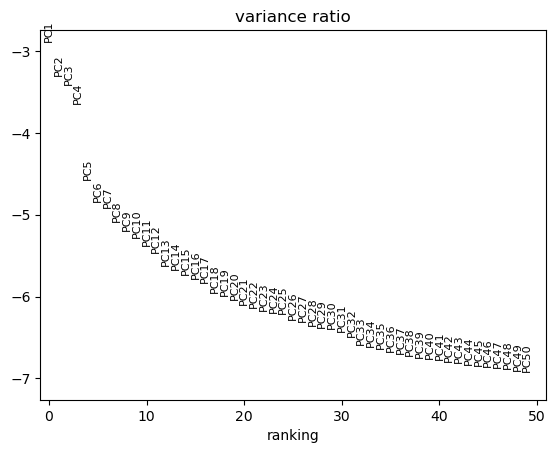

In [2]:
sc.pp.highly_variable_genes(adata, n_top_genes=2000, batch_key='sample', flavor='seurat')

adata.raw = adata  # keep full log-normalized gene set for later marker/DE lookups

adata_hvg = adata[:, adata.var['highly_variable']].copy()
sc.pp.scale(adata_hvg, max_value=10)
sc.tl.pca(adata_hvg, svd_solver='arpack', n_comps=50)

sc.pl.pca_variance_ratio(adata_hvg, n_pcs=50, log=True)

## Batch correction, clustering, and UMAP

Sample-level batch effects are corrected using Harmony. Neighbors, UMAP, and Leiden 
clustering are then computed on the Harmony-corrected PCA embedding (30 PCs, chosen 
based on the variance ratio elbow).

2026-09-23 12:57:38,757 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...
2026-09-23 12:57:41,062 - harmonypy - INFO - sklearn.KMeans initialization complete.
2026-09-23 12:57:41,135 - harmonypy - INFO - Iteration 1 of 10
2026-09-23 12:57:45,250 - harmonypy - INFO - Iteration 2 of 10
2026-09-23 12:57:49,506 - harmonypy - INFO - Iteration 3 of 10
2026-09-23 12:57:53,643 - harmonypy - INFO - Iteration 4 of 10
2026-09-23 12:57:57,857 - harmonypy - INFO - Iteration 5 of 10
2026-09-23 12:58:01,954 - harmonypy - INFO - Iteration 6 of 10
2026-09-23 12:58:06,088 - harmonypy - INFO - Iteration 7 of 10
2026-09-23 12:58:10,141 - harmonypy - INFO - Converged after 7 iterations


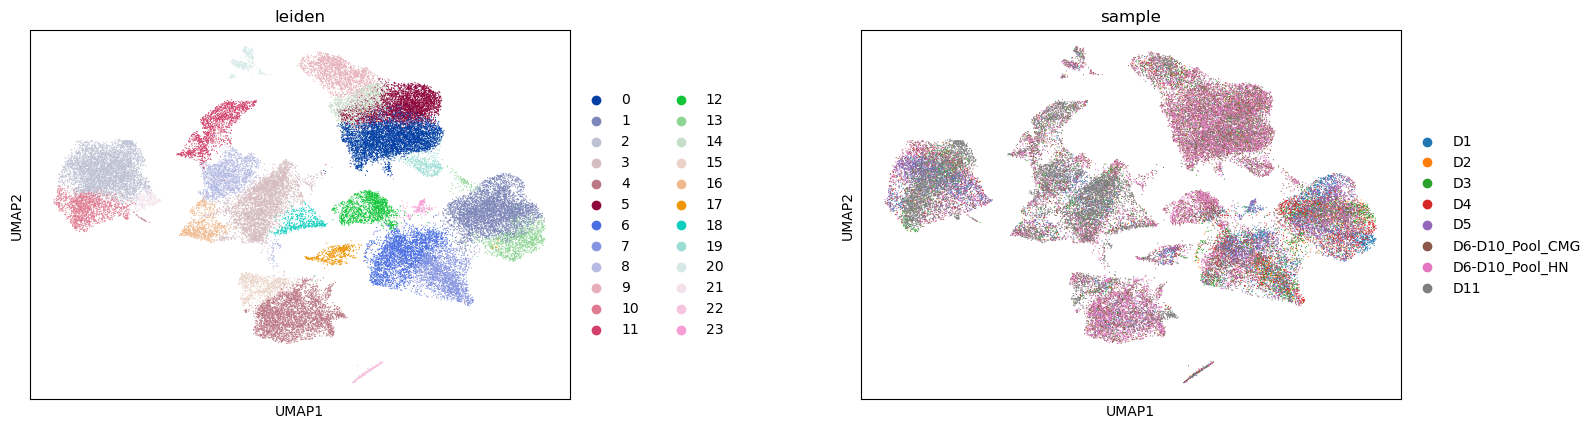

Number of clusters: 24


In [7]:
sce.pp.harmony_integrate(adata_hvg, 'sample')

sc.pp.neighbors(adata_hvg, n_neighbors=15, n_pcs=30, use_rep='X_pca_harmony')
sc.tl.umap(adata_hvg)
sc.tl.leiden(adata_hvg, resolution=1.0)

sc.pl.umap(adata_hvg, color=['leiden', 'sample'], wspace=0.4)
print(f"Number of clusters: {adata_hvg.obs['leiden'].nunique()}")

## Major cell type annotation

Clusters are annotated using canonical marker genes for epithelial, T cell, NK cell, 
myeloid, endothelial, and fibroblast populations.

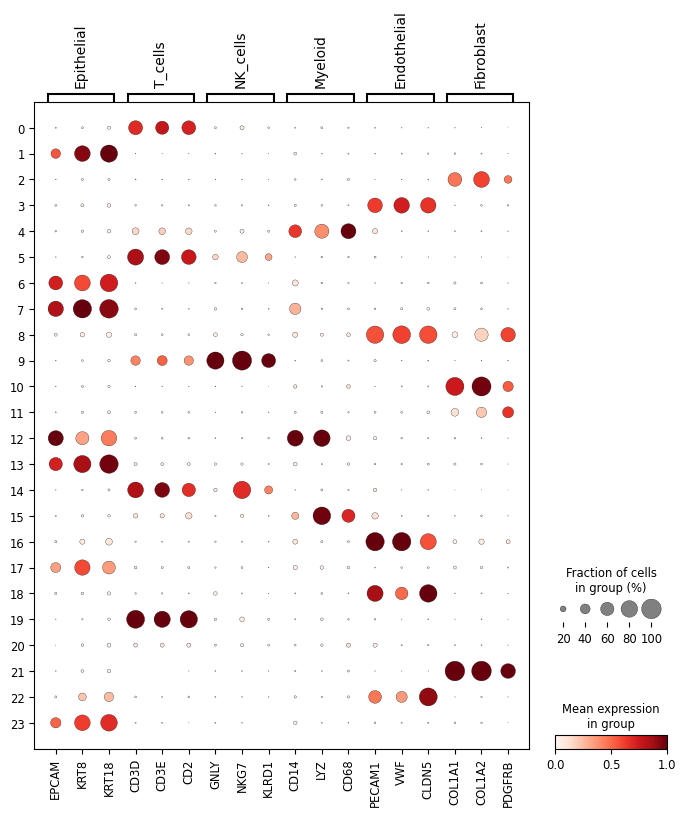

In [8]:
marker_genes = {
    'Epithelial': ['EPCAM', 'KRT8', 'KRT18'],
    'T_cells': ['CD3D', 'CD3E', 'CD2'],
    'NK_cells': ['GNLY', 'NKG7', 'KLRD1'],
    'Myeloid': ['CD14', 'LYZ', 'CD68'],
    'Endothelial': ['PECAM1', 'VWF', 'CLDN5'],
    'Fibroblast': ['COL1A1', 'COL1A2', 'PDGFRB'],
}

sc.pl.dotplot(adata_hvg, marker_genes, groupby='leiden', use_raw=True, standard_scale='var')

Based on the dotplot above, clusters are manually assigned to major cell types.


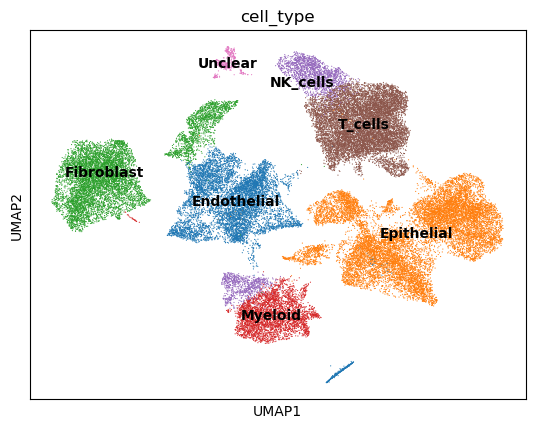

cell_type
Epithelial     13247
T_cells        10305
Fibroblast      8138
Endothelial     7521
Myeloid         3697
NK_cells        2595
Unclear          355
Name: count, dtype: int64


In [9]:
cluster_to_celltype = {
    '0': 'T_cells', '1': 'Epithelial', '2': 'Fibroblast', '3': 'Endothelial',
    '4': 'Myeloid', '5': 'T_cells', '6': 'Epithelial', '7': 'Epithelial',
    '8': 'Endothelial', '9': 'NK_cells', '10': 'Fibroblast', '11': 'Fibroblast',
    '12': 'Epithelial', '13': 'Epithelial', '14': 'T_cells', '15': 'NK_cells',
    '16': 'Endothelial', '17': 'Epithelial', '18': 'Endothelial', '19': 'T_cells',
    '20': 'Unclear', '21': 'Fibroblast', '22': 'Endothelial', '23': 'Epithelial',
}

adata_hvg.obs['cell_type'] = adata_hvg.obs['leiden'].map(cluster_to_celltype)
sc.pl.umap(adata_hvg, color='cell_type', legend_loc='on data')

print(adata_hvg.obs['cell_type'].value_counts())

## Save checkpoint

In [10]:
adata_hvg.write('checkpoints/adata_full_annotated.h5ad')